# Feature Engineering Pipeline (Robust & No-Leakage)

Questo notebook implementa una pipeline completa di Feature Engineering per il dataset GUIDE (Microsoft Incident Prediction).

**Obiettivo:** Trasformare i dati grezzi (livello Evidence) in un dataset pronto per il Machine Learning (livello Incident), mantenendo una rigorosa separazione tra Train e Test per evitare Data Leakage.

**Step Principali:**
1.  **Caricamento:** Importazione di `GUIDE_Train` e `GUIDE_Test`.
2.  **Target Engineering:** Definizione della variabile target (Binary: TruePositive vs Altri).
3.  **Evidence-Level Engineering:**
    *   Encoding Temporale
    *   *Smoothed Risk Score* (Calcolato su Train, applicato a Test)
    *   *Frequency Encoding* (Calcolato su Train, applicato a Test)
    *   Parsing Tecniche MITRE
4.  **Incident-Level Aggregation:** Aggregazione delle evidenze per ottenere una riga per Incidente.
5.  **Visual Analysis & Undersampling:** Analisi delle correlazioni e bilanciamento delle classi.
6.  **Export:** Salvataggio dei dataset processati.

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurazioni
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
%matplotlib inline
sns.set_style('whitegrid')

# Percorsi
DATA_DIR = '../data'
OUTPUT_DIR = '../data/processed_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup completato. Output directory:", OUTPUT_DIR)

Setup completato. Output directory: ../data/processed_final


## 1. Caricamento Dati

In [2]:
print("Caricamento dataset...")
# Carichiamo i dataset originali
train_df = pd.read_csv(os.path.join(DATA_DIR, 'GUIDE_Train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'GUIDE_Test.csv'))

print(f"Train shape originale: {train_df.shape}")
print(f"Test shape originale:  {test_df.shape}")

# --- RIDUZIONE TEST SET E RIUTILIZZO CAMPIONI EXTRA ---
# Obiettivo: 10k incidents per classe nel test, il resto va nel training

# Prima creiamo il target nel test per poter fare lo split stratificato
test_df_clean = test_df.dropna(subset=['IncidentGrade']).copy()
test_df_clean['Target'] = (test_df_clean['IncidentGrade'] == 'TruePositive').astype(int)

# Conta incidents unici per classe nel test
test_incident_targets = test_df_clean.groupby('IncidentId')['Target'].first().reset_index()
print(f"\nTest incidents totali: {len(test_incident_targets)}")
print(f"Distribuzione: {test_incident_targets['Target'].value_counts().to_dict()}")

# Campiona 10k incidents per classe per il test finale
TEST_SAMPLES_PER_CLASS = 10000

test_final_ids = []
for target_class in [0, 1]:
    class_incidents = test_incident_targets[test_incident_targets['Target'] == target_class]['IncidentId']
    if len(class_incidents) > TEST_SAMPLES_PER_CLASS:
        sampled = class_incidents.sample(n=TEST_SAMPLES_PER_CLASS, random_state=42)
    else:
        sampled = class_incidents
        print(f"⚠️ Classe {target_class}: solo {len(class_incidents)} incidents disponibili")
    test_final_ids.extend(sampled.tolist())

test_final_ids = set(test_final_ids)
extra_ids = set(test_incident_targets['IncidentId']) - test_final_ids

print(f"\n--- Riallocazione Test Set ---")
print(f"Test Finale: {len(test_final_ids)} incidents (10k per classe)")
print(f"Extra (→ Training): {len(extra_ids)} incidents")

# Separa i dataframe a livello evidence
test_final_df = test_df_clean[test_df_clean['IncidentId'].isin(test_final_ids)].copy()
test_extra_df = test_df_clean[test_df_clean['IncidentId'].isin(extra_ids)].copy()

# --- VERIFICA ANTI-LEAKAGE ---
overlap = test_final_ids & extra_ids
assert len(overlap) == 0, f"ERRORE: {len(overlap)} incident in entrambi i set!"

# Verifica che TUTTE le evidence siano state assegnate
total_evidence_check = len(test_final_df) + len(test_extra_df)
assert total_evidence_check == len(test_df_clean), f"ERRORE: evidence perse! {total_evidence_check} vs {len(test_df_clean)}"

print(f"\n✅ Verifica Anti-Leakage:")
print(f"   - Overlap incidents: {len(overlap)} (deve essere 0)")
print(f"   - Evidence test finale: {len(test_final_df)}")
print(f"   - Evidence extra → train: {len(test_extra_df)}")
print(f"   - Totale evidence: {total_evidence_check} == {len(test_df_clean)} ✓")

# Aggiungi i campioni extra al training set PRIMA di qualsiasi encoding
train_df = pd.concat([train_df, test_extra_df], ignore_index=True)

# Aggiorna test_df per usare solo il test finale
test_df = test_final_df.copy()

print(f"\n--- Shape Finali Pre-Engineering ---")
print(f"Train (originale + extra): {train_df.shape}")
print(f"Test Finale:               {test_df.shape}")

Caricamento dataset...
Train shape originale: (9516837, 45)
Test shape originale:  (4147992, 46)

Test incidents totali: 236267
Distribuzione: {0: 186713, 1: 49554}

--- Riallocazione Test Set ---
Test Finale: 20000 incidents (10k per classe)
Extra (→ Training): 216267 incidents

✅ Verifica Anti-Leakage:
   - Overlap incidents: 0 (deve essere 0)
   - Evidence test finale: 409490
   - Evidence extra → train: 3738502
   - Totale evidence: 4147992 == 4147992 ✓

--- Shape Finali Pre-Engineering ---
Train (originale + extra): (13255339, 47)
Test Finale:               (409490, 47)


## 2. Pulizia e Preparazione Iniziale
Rimuoviamo le righe senza target nel training set e definiamo la variabile target binaria.

In [3]:
# Rimuovi righe senza IncidentGrade nel Train (se presenti)
train_df = train_df.dropna(subset=['IncidentGrade'])

# Definizione Target Binario: 1 se TruePositive, 0 altrimenti
# (alcuni record già hanno Target dai dati extra, ricreiamolo per uniformità)
train_df['Target'] = (train_df['IncidentGrade'] == 'TruePositive').astype(int)

# Il test_df ha già il Target dalla cella precedente
print("Target distribution (Train - include extra samples):")
print(train_df['Target'].value_counts(normalize=True))
print(f"\nTotale Incidents nel Train Pool: {train_df['IncidentId'].nunique()}")

# --- SPLIT A LIVELLO INCIDENT PRIMA DEL TARGET ENCODING ---
# Questo previene data leakage nel validation set
from sklearn.model_selection import train_test_split

# Ottieni lista unica di IncidentId con il loro target (a livello incident)
incident_targets = train_df.groupby('IncidentId')['Target'].first().reset_index()

# Split stratificato degli IncidentId (90% train, 10% validation)
train_incidents, val_incidents = train_test_split(
    incident_targets['IncidentId'],
    test_size=0.1,
    random_state=42,
    stratify=incident_targets['Target']
)

# Separa i dataframe a livello evidence
train_fold = train_df[train_df['IncidentId'].isin(train_incidents)].copy()
val_fold = train_df[train_df['IncidentId'].isin(val_incidents)].copy()

print(f"\n--- Split Anti-Leakage (con Extra Samples) ---")
print(f"Train Incidents: {len(train_incidents)} ({len(train_fold)} evidences)")
print(f"Val Incidents:   {len(val_incidents)} ({len(val_fold)} evidences)")
print(f"Test Incidents:  {test_df['IncidentId'].nunique()} ({len(test_df)} evidences)")

Target distribution (Train - include extra samples):
Target
0    0.653751
1    0.346249
Name: proportion, dtype: float64

Totale Incidents nel Train Pool: 564747

--- Split Anti-Leakage (con Extra Samples) ---
Train Incidents: 508272 (11883697 evidences)
Val Incidents:   56475 (1320302 evidences)
Test Incidents:  20000 (409490 evidences)


## 3. Feature Engineering (Evidence Level)

In questa fase creiamo nuove feature per ogni evidenza. 
**Regola d'oro:** Qualsiasi statistica globale (medie, frequenze) deve essere calcolata SOLO sul Train e poi applicata (mappata) sul Test.

### 3.1 Features Temporali

In [4]:
def extract_time_features(df):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    return df

train_fold = extract_time_features(train_fold)
val_fold = extract_time_features(val_fold)
test_df = extract_time_features(test_df)
print("Features temporali estratte.")

Features temporali estratte.


### 3.2 Smoothed Risk Encoding (Target Encoding)
Calcoliamo la probabilità che un certo `AlertTitle` sia un True Positive. Usiamo lo *smoothing* per evitare overfitting su categorie rare.
Calcoliamo la mappa su `train_df` e la applichiamo a entrambi.

In [5]:
# Parametri per smoothing bayesiano
alpha = 5  # Prior weight
global_mean = train_fold['Target'].mean()  # Calcolato SOLO su train_fold!

# Calcolo statistiche SOLO su TRAIN_FOLD (no leakage)
stats = train_fold.groupby('AlertTitle')['Target'].agg(['count', 'mean'])
smoothed_score = (stats['count'] * stats['mean'] + alpha * global_mean) / (stats['count'] + alpha)
risk_map = smoothed_score.to_dict()

# Applicazione a tutti i dataset
train_fold['AlertRisk'] = train_fold['AlertTitle'].map(risk_map).fillna(global_mean)
val_fold['AlertRisk'] = val_fold['AlertTitle'].map(risk_map).fillna(global_mean)
test_df['AlertRisk'] = test_df['AlertTitle'].map(risk_map).fillna(global_mean)

print("Smoothed Risk calcolato su train_fold e applicato a train/val/test.")

Smoothed Risk calcolato su train_fold e applicato a train/val/test.


### 3.3 Frequency Encoding & GeoLocation
Codifichiamo variabili categoriche ad alta cardinalità con la loro frequenza nel training set.

In [6]:
# Creazione feature combinata Geografica
for df in [train_fold, val_fold, test_df]:
    df['GeoLoc'] = df['CountryCode'].astype(str) + '_' + df['State'].astype(str) + '_' + df['City'].astype(str)

# Colonne da codificare in frequenza
freq_cols = ['GeoLoc', 'DeviceName', 'FileName', 'IpAddress', 'Url']

for col in freq_cols:
    # Calcola frequenza SOLO su TRAIN_FOLD (no leakage)
    freq_map = train_fold[col].value_counts(normalize=True).to_dict()
    
    # Applica a tutti (con 0 per valori nuovi)
    train_fold[f'{col}_Freq'] = train_fold[col].map(freq_map).fillna(0)
    val_fold[f'{col}_Freq'] = val_fold[col].map(freq_map).fillna(0)
    test_df[f'{col}_Freq'] = test_df[col].map(freq_map).fillna(0)

print(f"Frequency encoding applicato su: {freq_cols}")

Frequency encoding applicato su: ['GeoLoc', 'DeviceName', 'FileName', 'IpAddress', 'Url']


### 3.4 MITRE Techniques Processing
Estraiamo le tecniche più comuni (Top 20) e creiamo flag binari.

In [7]:
# Parsing della colonna (stringa separata da ;)
def parse_techniques(series):
    return series.fillna('').astype(str).apply(lambda x: x.split(';') if x else [])

train_techs = parse_techniques(train_fold['MitreTechniques'])
val_techs = parse_techniques(val_fold['MitreTechniques'])
test_techs = parse_techniques(test_df['MitreTechniques'])

# Identifica le Top 20 tecniche SOLO nel TRAIN_FOLD (no leakage)
all_train_techs = [t for sublist in train_techs for t in sublist if t]
top_techs = [t for t, count in Counter(all_train_techs).most_common(20)]  # FIX: era t[0]

print("Top MITRE Techniques:", top_techs)

# One-Hot Encoding manuale per le top tecniche
for tech in top_techs:
    clean_tech_name = tech.replace('.', '_')  # Pulisci nome colonna
    train_fold[f'Mitre_{clean_tech_name}'] = train_fold['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)
    val_fold[f'Mitre_{clean_tech_name}'] = val_fold['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)
    test_df[f'Mitre_{clean_tech_name}'] = test_df['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)

# Conteggio totale tecniche
train_fold['Mitre_Count'] = train_techs.apply(len)
val_fold['Mitre_Count'] = val_techs.apply(len)
test_df['Mitre_Count'] = test_techs.apply(len)

Top MITRE Techniques: ['T1078', 'T1078.004', 'T1566.002', 'T1566', 'T1110', 'T1133', 'T1566.001', 'T1110.003', 'T1110.001', 'T1071', 'T1087', 'T1046', 'T1087.002', 'T1190', 'T1098', 'T1059.005', 'T1210', 'T1030', 'T1559', 'T1106']


## 4. Aggregazione a Livello di Incidente
Ora comprimiamo le righe. Ogni `IncidentId` avrà una sola riga nel dataset finale. 
Le features delle evidenze verranno aggregate (media, somma, max, ecc.).

In [8]:
def aggregate_incidents(df):
    # Definiamo il dizionario di aggregazione
    agg_dict = {
        'Target': 'max',  # Se almeno una evidenza è TP, l'incidente è TP
        'AlertId': 'nunique',  # Numero di alert unici
        'Id': 'count',  # Numero totale di evidenze
        'AlertRisk': ['mean', 'max'],
        'Hour': ['mean', 'std'],
        'IsWeekend': 'mean',  # % di evidenze nel weekend
        'Mitre_Count': 'sum',
        # Rimosso OrgId per evitare overfitting su ID categorici
    }
    
    # Aggiungi aggregazioni per colonne frequenza
    for col in freq_cols:
        agg_dict[f'{col}_Freq'] = ['mean', 'max']
        
    # Aggiungi aggregazioni per colonne MITRE (max = presenza nell'incidente)
    mitre_cols = [c for c in df.columns if c.startswith('Mitre_') and c != 'Mitre_Count']
    for col in mitre_cols:
        agg_dict[col] = 'max'

    # Esegui GroupBy
    print("Esecuzione aggregazione...")
    df_agg = df.groupby('IncidentId').agg(agg_dict)
    
    # Appiattisci i nomi delle colonne (es. AlertRisk_mean)
    df_agg.columns = ['_'.join(col).strip() for col in df_agg.columns.values]
    df_agg.reset_index(inplace=True)
    
    # Rinomina alcune colonne chiave
    df_agg.rename(columns={'Target_max': 'Target', 'Id_count': 'EvidenceCount', 'AlertId_nunique': 'AlertCount'}, inplace=True)
    
    return df_agg

print("Aggregazione Train Fold...")
train_agg = aggregate_incidents(train_fold)

print("Aggregazione Validation Fold...")
val_agg = aggregate_incidents(val_fold)

print("Aggregazione Test Set...")
test_agg = aggregate_incidents(test_df)

print(f"\nTrain Aggregated Shape: {train_agg.shape}")
print(f"Val Aggregated Shape:   {val_agg.shape}")
print(f"Test Aggregated Shape:  {test_agg.shape}")

Aggregazione Train Fold...
Esecuzione aggregazione...
Aggregazione Validation Fold...
Esecuzione aggregazione...
Aggregazione Test Set...
Esecuzione aggregazione...

Train Aggregated Shape: (508272, 40)
Val Aggregated Shape:   (56475, 40)
Test Aggregated Shape:  (20000, 40)


## 5. Visual Analysis & Undersampling
Verifichiamo l'utilità delle feature e bilanciamo le classi.

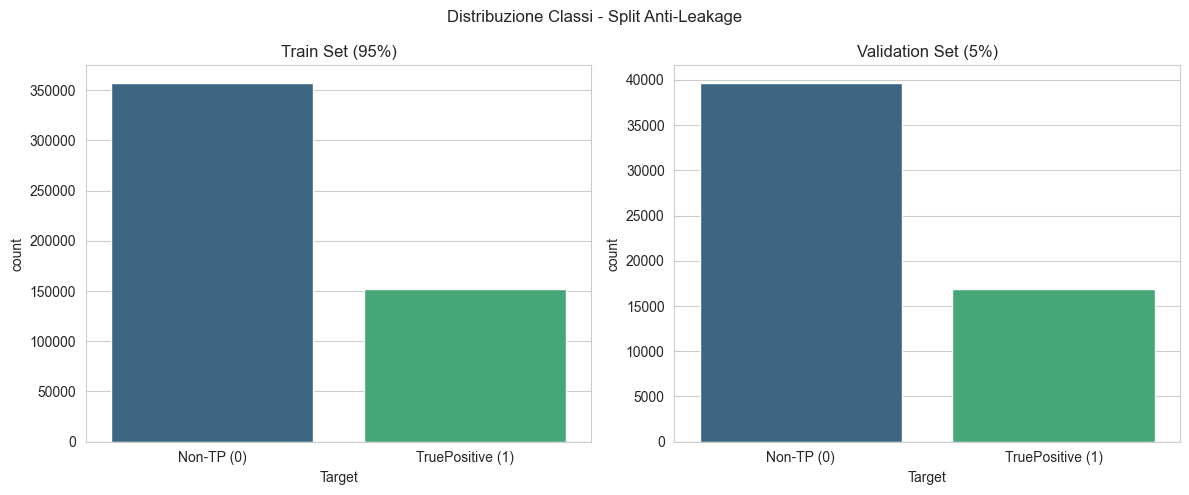

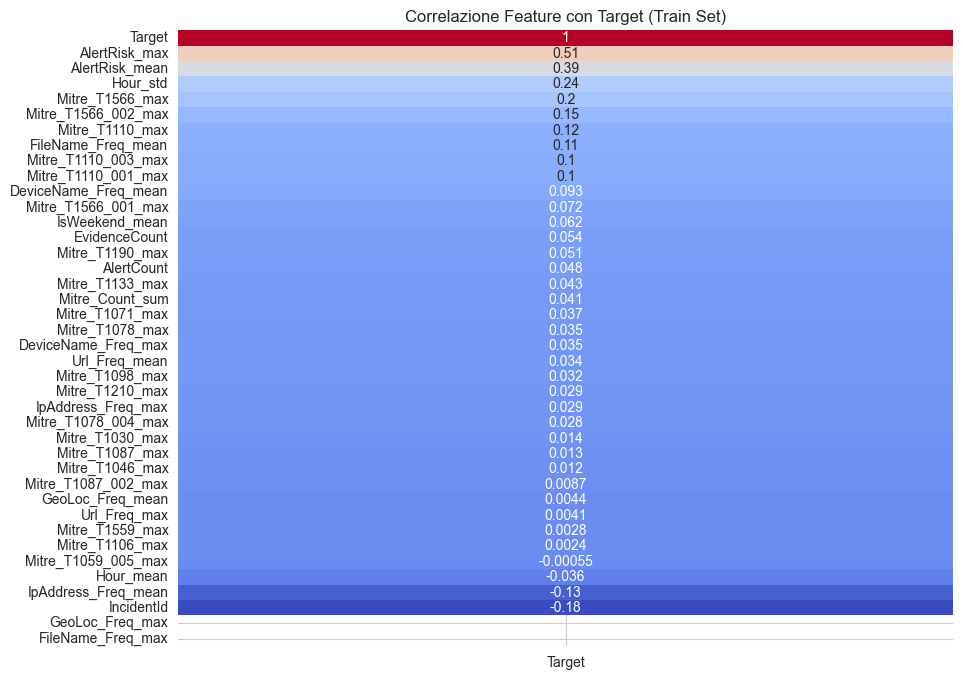

Top 10 Feature Correlate positivamente:
Target                 1.000000
AlertRisk_max          0.510857
AlertRisk_mean         0.385727
Hour_std               0.235309
Mitre_T1566_max        0.201731
Mitre_T1566_002_max    0.149481
Mitre_T1110_max        0.117237
FileName_Freq_mean     0.112704
Mitre_T1110_003_max    0.104850
Mitre_T1110_001_max    0.103146
Name: Target, dtype: float64


In [9]:
# Analisi Distribuzione Classi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Target', data=train_agg, palette='viridis', ax=axes[0])
axes[0].set_title('Train Set (95%)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-TP (0)', 'TruePositive (1)'])

sns.countplot(x='Target', data=val_agg, palette='viridis', ax=axes[1])
axes[1].set_title('Validation Set (5%)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-TP (0)', 'TruePositive (1)'])

plt.suptitle('Distribuzione Classi - Split Anti-Leakage')
plt.tight_layout()
plt.show()

# Analisi Correlazione con il Target (solo train)
numeric_cols = train_agg.select_dtypes(include=[np.number]).columns
correlation = train_agg[numeric_cols].corr()['Target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Correlazione Feature con Target (Train Set)')
plt.show()

print("Top 10 Feature Correlate positivamente:")
print(correlation.head(10))

In [10]:
# --- UNDERSAMPLING (su Train e Validation) ---
print("Esecuzione Undersampling della classe maggioritaria...")

def undersample_dataset(df, name="Dataset"):
    """Applica undersampling per bilanciare le classi."""
    df_majority = df[df.Target == 0]
    df_minority = df[df.Target == 1]
    
    print(f"\n{name}:")
    print(f"  Classe Maggioritaria (0): {len(df_majority)}")
    print(f"  Classe Minoritaria (1): {len(df_minority)}")
    
    # Undersample della maggioritaria
    df_majority_downsampled = resample(df_majority, 
                                       replace=False,
                                       n_samples=len(df_minority),
                                       random_state=42) 
    
    # Combinazione e shuffle
    df_balanced = pd.concat([df_majority_downsampled, df_minority])
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"  Bilanciato: {df_balanced.shape[0]} samples")
    return df_balanced

# Applica undersampling a entrambi
train_balanced = undersample_dataset(train_agg, "Train Set")
val_balanced = undersample_dataset(val_agg, "Validation Set")

print("\n--- Riepilogo Finale ---")
print(f"Train Bilanciato: {train_balanced['Target'].value_counts().to_dict()}")
print(f"Val Bilanciato:   {val_balanced['Target'].value_counts().to_dict()}")

Esecuzione Undersampling della classe maggioritaria...

Train Set:
  Classe Maggioritaria (0): 356666
  Classe Minoritaria (1): 151606
  Bilanciato: 303212 samples

Validation Set:
  Classe Maggioritaria (0): 39610
  Classe Minoritaria (1): 16865
  Bilanciato: 33730 samples

--- Riepilogo Finale ---
Train Bilanciato: {0: 151606, 1: 151606}
Val Bilanciato:   {0: 16865, 1: 16865}


## 6. Salvataggio Output
Salviamo i file pronti per l'addestramento dei modelli. 
**Nota:** Salviamo sia la versione sbilanciata (`train_final.csv`) che quella bilanciata (`train_balanced.csv`) per poter sperimentare.

In [11]:
# Fill NaN generati dall'aggregazione (es. std su un solo elemento)
train_agg.fillna(0, inplace=True)
train_balanced.fillna(0, inplace=True)
val_agg.fillna(0, inplace=True)
val_balanced.fillna(0, inplace=True)
test_agg.fillna(0, inplace=True)

# Salvataggio
train_agg.to_csv(os.path.join(OUTPUT_DIR, 'train_final_imbalanced.csv'), index=False)
train_balanced.to_csv(os.path.join(OUTPUT_DIR, 'train_final_balanced.csv'), index=False)
val_agg.to_csv(os.path.join(OUTPUT_DIR, 'val_final_imbalanced.csv'), index=False)
val_balanced.to_csv(os.path.join(OUTPUT_DIR, 'val_final.csv'), index=False)  # Validation bilanciato
test_agg.to_csv(os.path.join(OUTPUT_DIR, 'test_final.csv'), index=False)

# Salva anche versione combinata train+val per compatibilità (opzionale)
train_full = pd.concat([train_agg, val_agg], ignore_index=True)
train_full.to_csv(os.path.join(OUTPUT_DIR, 'train_final.csv'), index=False)

# Salvataggio delle mappature per inferenza futura
mappings = {
    'risk_map': risk_map,
    'top_techs': top_techs,
    'global_mean': global_mean,
    'freq_cols': freq_cols
}
with open(os.path.join(OUTPUT_DIR, 'feature_mappings.pkl'), 'wb') as f:
    pickle.dump(mappings, f)

print("Dataset salvati in", OUTPUT_DIR)
print("- train_final_imbalanced.csv (90% train, sbilanciato)")
print("- train_final_balanced.csv (90% train, undersampled)")
print("- val_final_imbalanced.csv (10% validation, sbilanciato)")
print("- val_final.csv (10% validation, undersampled)")
print("- test_final.csv (GUIDE_Test)")
print("- train_final.csv (train+val combinati, sbilanciato)")
print("- feature_mappings.pkl")

Dataset salvati in ../data/processed_final
- train_final_imbalanced.csv (90% train, sbilanciato)
- train_final_balanced.csv (90% train, undersampled)
- val_final_imbalanced.csv (10% validation, sbilanciato)
- val_final.csv (10% validation, undersampled)
- test_final.csv (GUIDE_Test)
- train_final.csv (train+val combinati, sbilanciato)
- feature_mappings.pkl
